In [8]:
import numpy as np
import pandas as pd
import neurokit2 as nk
from pathlib import Path
from tqdm import tqdm
import time
import matplotlib.pyplot as plt

from scipy.signal import resample_poly

WINDOWING SAMPLERATE AND OVERLAP

In [9]:
FS = 200                     # Sampling frequency (Hz)
WINDOW_SEC = 60             # Sliding window length (seconds)
WINDOW_SAMPLES = FS * WINDOW_SEC
STEP_SEC = 15                # Step size (seconds)


 Resample signal using polyphase filtering

In [10]:
def resample_signal(signal, fs_in=256, fs_out=200):

    return resample_poly(signal, fs_out, fs_in)

In [ ]:
import warnings
warnings.filterwarnings("ignore")



In [35]:
def eda_function (df, participant_id):

    # -------- PARAMETERS --------
    RAW_FS = 256     # din original sampling
    TARGET_FS = 32  # bättre för EDA

    # -------- LOAD & CLEAN --------
    eda = pd.to_numeric(df["gsr"], errors="coerce")
    eda = eda.interpolate().bfill().ffill()

    print("Raw EDA stats:")
    print("Min:", np.min(eda), "Max:", np.max(eda), "Std:", np.std(eda))

    # -------- REMOVE SPIKES --------
    q1, q99 = np.percentile(eda, [1, 99])
    eda_clipped = np.clip(eda, q1, q99)

    # -------- RESAMPLE --------
    eda_resampled = resample_signal(eda_clipped.values, RAW_FS, TARGET_FS)
    FS = TARGET_FS
    trim_sec = 5
    eda_resampled = eda_resampled[FS*trim_sec : -FS*trim_sec]

    print("\nAfter resampling:")
    print("Length:", len(eda_resampled), "Samples")
    print("Duration (sec):", len(eda_resampled) / FS)

    # -------- CLEAN (FILTER) --------
    eda_clean = nk.eda_clean(eda_resampled, sampling_rate=FS, method="neurokit")

    # -------- DECOMPOSE --------
    eda_decomp = nk.eda_phasic(
        eda_clean,
        sampling_rate=FS,
        method="highpass"
    )

    EDA_Tonic = eda_decomp["EDA_Tonic"].values
    EDA_Phasic = eda_decomp["EDA_Phasic"].values

    EDA_Phasic = np.maximum(EDA_Phasic, 0)
    
    amp_threshold = 0.05 * np.std(EDA_Phasic)

    # -------- SCR DETECTION --------
    signals_scr, info_scr = nk.eda_peaks(
        EDA_Phasic,
        sampling_rate=FS,
        method="neurokit",
        amplitude_min=amp_threshold
    )

    SCR_peaks = signals_scr["SCR_Peaks"].values

    print("\nSCR count:", int(np.sum(SCR_peaks)))

    # =========================
    # PLOTTING
    # =========================

    time = np.arange(len(eda_clean)) / FS

    plt.figure(figsize=(14, 10))

    # 1. Raw vs Clean
    plt.subplot(4,1,1)
    plt.plot(time, eda_resampled, label="Resampled Raw", alpha=0.5)
    plt.plot(time, eda_clean, label="Clean", linewidth=2)
    plt.title("EDA Raw vs Clean")
    plt.legend()

    # 2. Tonic
    plt.subplot(4,1,2)
    plt.plot(time, EDA_Tonic, color="green")
    plt.title("EDA Tonic (Baseline)")

    # 3. Phasic
    plt.subplot(4,1,3)
    plt.plot(time, EDA_Phasic, color="red")
    plt.title("EDA Phasic (Responses)")

    # 4. SCR peaks
    plt.subplot(4,1,4)
    plt.plot(time, EDA_Phasic, color="red", label="Phasic")
    plt.scatter(time[SCR_peaks == 1], EDA_Phasic[SCR_peaks == 1], color="black", label="SCR Peaks")
    plt.title("SCR Detection")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
import pandas as pd

# -------------------------
# DATA PATH
# -------------------------
DATA_DIR = Path("../data/raw/Participants")

# -------------------------
# Collect participant files
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)

print("Found files:", len(participant_files))
print("Example files:")
for f in participant_files[:5]:
    print(f)

# -------------------------
# SELECT PARTICIPANT
# -------------------------
SELECT_PARTICIPANT = "Part55"   # <-- ändra här

# hitta rätt fil
matches = [f for f in participant_files if f.parent.name == SELECT_PARTICIPANT]

if len(matches) == 0:
    print("Participant not found!")
else:
    file = matches[0]
    print("\nLoading:", file)

    df = pd.read_csv(file)

    # kör din EDA debug funktion
    eda_function(df, SELECT_PARTICIPANT)

In [15]:
def extract_features_ppg(df, participant_id):

    import numpy as np
    import neurokit2 as nk

    # -------------------------
    # LOAD
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")

    # fill missing values
    ppg = ppg.interpolate().bfill().ffill()

    # -------------------------
    # RESAMPLE
    # -------------------------
    ppg = resample_signal(ppg.values, 256, 200)

    # -------------------------
    # TRIM EDGES (2 sec)
    # -------------------------
    ppg = ppg[FS*2:-FS*2]

    print("\n=== SIGNAL INFO ===")
    print("Signal length (samples):", len(ppg))
    print("Signal length (seconds):", len(ppg) / FS)

    # -------------------------
    # PPG PROCESSING
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(
        ppg,
        sampling_rate=FS,
        method="elgendi",
        method_peaks="charlton"
    )

    signal_clean = signals_ppg["PPG_Clean"].values
    rpeaks = info_ppg["PPG_Peaks"]

    # -------------------------
    # CENTROID REFINEMENT
    # -------------------------
    def refine_peaks_centroid(signal, peaks, fs, window=0.05):
        refined = []
        w = int(window * fs)

        for p in peaks:
            start = max(0, p - w)
            end = min(len(signal), p + w)

            segment = signal[start:end]
            x = np.arange(start, end)

            y = segment - np.min(segment)

            if np.sum(y) == 0 or len(segment) == 0:
                refined.append(p)
                continue

            centroid = np.sum(x * y) / np.sum(y)
            refined.append(int(centroid))

        return np.array(refined)

    rpeaks = refine_peaks_centroid(signal_clean, rpeaks, FS)

    # -------------------------
    # RR INTERVALS
    # -------------------------
    rr_intervals = np.diff(rpeaks) / FS * 1000  # ms
    rr_times = (rpeaks[1:] + rpeaks[:-1]) / 2

    features = []

    step_samples = FS * STEP_SEC
    signal_len = len(signal_clean)

    print("\n=== WINDOW SETTINGS ===")
    print("Window samples:", WINDOW_SAMPLES)
    print("Step samples:", step_samples)
    print("Step (seconds):", step_samples / FS)
    print("Expected windows (rough):", int((signal_len - WINDOW_SAMPLES) / step_samples + 1))

    # -------------------------
    # SLIDING WINDOWS
    # -------------------------
    for start in range(0, signal_len - WINDOW_SAMPLES + 1, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # -------------------------
        # HR
        # -------------------------
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # -------------------------
        # RR SELECTION
        # -------------------------
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        # -------------------------
        # RR FILTERING
        # -------------------------
        rr_win = rr_win[(rr_win > 400) & (rr_win < 1200)]

        if len(rr_win) >= 10:

            diff_rr = np.diff(rr_win)
            valid_diff = np.abs(diff_rr) < 150
            diff_rr = diff_rr[valid_diff]

            rr_quality = np.sum(valid_diff) / len(valid_diff)

            # -------------------------
            # HRV
            # -------------------------
            if len(diff_rr) > 0:
                window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
                window["RR_diff_std"] = np.std(diff_rr)
            else:
                window["HRV_RMSSD"] = np.nan
                window["RR_diff_std"] = np.nan

            window["HRV_SDNN"] = np.std(rr_win, ddof=1)

            # -------------------------
            # RR DIAGNOSTICS
            # -------------------------
            window["RR_mean"] = np.mean(rr_win)
            window["RR_std"] = np.std(rr_win)
            window["RR_min"] = np.min(rr_win)
            window["RR_max"] = np.max(rr_win)
            window["RR_count"] = len(rr_win)
            window["RR_quality"] = rr_quality
            window["RR_valid"] = 1

        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan
            window["RR_mean"] = np.nan
            window["RR_std"] = np.nan
            window["RR_min"] = np.nan
            window["RR_max"] = np.nan
            window["RR_count"] = 0
            window["RR_diff_std"] = np.nan
            window["RR_quality"] = 0
            window["RR_valid"] = 0

        # -------------------------
        # METADATA
        # -------------------------
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [41]:
def extract_eda_huysmans_from_df(df, participant_id):

    import numpy as np
    import neurokit2 as nk

    RAW_FS = 256
    TARGET_FS = 200
    FS = TARGET_FS

    # -------------------------
    # LOAD & CLEAN
    # -------------------------
    eda = pd.to_numeric(df["gsr"], errors="coerce")
    eda = eda.interpolate().bfill().ffill()

    # Remove extreme outliers (behåll denna)
    q_low, q_high = np.percentile(eda, [0.5, 99.5])
    eda = np.clip(eda, q_low, q_high)

    # -------------------------
    # RESAMPLE + TRIM
    # -------------------------
    eda = resample_signal(eda.values, RAW_FS, TARGET_FS)

    trim = FS * 5
    eda = eda[trim:-trim]

    # -------------------------
    # 🔥 NEUROKIT PIPELINE
    # -------------------------
    signals, info = nk.eda_process(eda, sampling_rate=FS)

    tonic = signals["EDA_Tonic"].values
    phasic = signals["EDA_Phasic"].values
    scr = signals["SCR_Peaks"].values

    # -------------------------
    # WINDOWING (60s)
    # -------------------------
    WINDOW_SEC = 60
    STEP_SEC = 15

    W = FS * WINDOW_SEC
    S = FS * STEP_SEC

    features = []

    for start in range(0, len(tonic) - W + 1, S):

        end = start + W

        tonic_win = tonic[start:end]
        phasic_win = phasic[start:end]
        scr_win = scr[start:end]

        # -------------------------
        # Huysmans features
        # -------------------------

        # SC_PH (phasic power)
        sc_ph = np.mean(phasic_win ** 2)

        # ⚠️ FIXAD VERSION av din cap (rätt domän)
        phasic_cap = np.percentile(phasic_win, 99)
        phasic_win_clipped = np.clip(phasic_win, 0, phasic_cap)
        sc_ph = np.mean(phasic_win_clipped ** 2)

        # SC_RR (SCR rate)
        sc_rr = np.sum(scr_win) / WINDOW_SEC

        # slope (tonic trend)
        x = np.arange(len(tonic_win))
        slope = np.polyfit(x, tonic_win, 1)[0]

        features.append({
            "SC_PH": sc_ph,
            "SC_RR": sc_rr,
            "EDA_slope": slope,
            "participant": participant_id,
            "time_sec": start // FS
        })

    return pd.DataFrame(features)

In [31]:
def extract_features_eda_ppg(df, participant_id):

    # -------------------------
    # EDA (Huysmans – din nya)
    # -------------------------
    eda_features = extract_eda_huysmans_from_df(df, participant_id)

    if eda_features is None or len(eda_features) == 0:
        return None

    # -------------------------
    # PPG (din befintliga)
    # OBS: använder samma df
    # -------------------------
    ppg_features = extract_features_ppg(df, participant_id)

    if ppg_features is None or len(ppg_features) == 0:
        return None

    # -------------------------
    # MERGE (viktig del)
    # -------------------------
    merged = pd.merge(
        ppg_features,
        eda_features,
        on=["participant", "time_sec"],
        how="inner"
    )

    return merged

In [6]:
def get_participant_files(data_dir, start=1, end=48):

    files = sorted(
        data_dir.rglob("full_gsr_ppg*.csv"),
        key=lambda x: int(x.parent.name.replace("Part", ""))
    )

    files = [
        f for f in files
        if start <= int(f.parent.name.replace("Part", "")) <= end
    ]

    return files

In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/raw/Participants")
OUTPUT_DIR = Path("../data/processed/eda_ppg_features_test2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# SELECT PARTICIPANTS
# -------------------------
participant_files = get_participant_files(DATA_DIR, 11,11)

print("Participants loaded:", len(participant_files))

# -------------------------
# Extract features
# -------------------------
all_features = []

for file in participant_files:

    participant_id = file.parent.name
    print("Processing:", participant_id)

    df = pd.read_csv(file)

   
    if df["gsr"].std() > 1000:
        print("⚠️ Noisy participant")
        continue


    features = extract_features_eda_ppg(df, participant_id)

    if features is None or len(features) == 0:
        continue

    # -------------------------
    # 💾 SAVE INDIVIDUAL
    # -------------------------
    output_file = OUTPUT_DIR / f"{participant_id}_features_test2.csv"
    features.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")

    all_features.append(features)

# -------------------------
# Combine ALL
# -------------------------
features_df = pd.concat(all_features, ignore_index=True)

# -------------------------
# 💾 SAVE GLOBAL
# -------------------------
features_df.to_csv(OUTPUT_DIR / "features_all_test12.csv", index=False)

print("\nDONE ✅")
print("Shape:", features_df.shape)

In [22]:
features_df.describe()

,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,time_sec,SC_PH,SC_RR,EDA_slope
count,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.000000,453.0,453.000000,453.000000,453.000000,453.000000
mean,79.539331,40.776142,40.753486,51.247555,759.699430,50.921874,640.055188,882.350993,79.474614,0.995614,1.0,1125.000000,43.376061,0.062215,0.000914
std,6.609851,8.450214,8.444412,13.384511,59.739882,13.298452,63.979802,63.856019,6.618718,0.010002,0.0,654.557711,107.725143,0.047275,0.010953
min,68.343380,20.662634,20.658974,23.775637,580.336538,23.643181,485.000000,695.000000,68.000000,0.920000,1.0,0.000000,0.019948,0.000000,-0.055768
25%,74.654447,34.913158,34.845179,41.639829,719.166667,41.355726,600.000000,845.000000,75.000000,1.000000,1.0,555.000000,0.817578,0.033333,-0.000690
50%,77.933372,40.684726,40.664069,49.076377,769.487179,48.799888,630.000000,890.000000,78.000000,1.000000,1.0,1125.000000,1.756776,0.050000,0.000505
75%,83.555741,46.682720,46.620754,61.318658,804.066667,60.902933,685.000000,930.000000,83.000000,1.000000,1.0,1695.000000,18.868915,0.083333,0.002754
max,103.459170,62.533775,62.494010,91.843975,877.647059,91.237738,815.000000,1050.000000,104.000000,1.000000,1.0,2250.000000,825.929634,0.200000,0.035043


In [ ]:
# =========================
# LOAD + EXTRACT + SAVE (GLOBAL + PER PARTICIPANT)
# =========================

from pathlib import Path
import pandas as pd

DATA_DIR = Path("../data/raw/Participants")
OUTPUT_DIR = Path("../data/processed/eda_features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Collect Part1–48
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)

participant_files = [
    f for f in participant_files
    if int(f.parent.name.replace("Part", "")) <= 48
]

print("Participants loaded:", len(participant_files))


# -------------------------
# Extract features
# -------------------------
all_features = []

for file in participant_files:

    participant_id = file.parent.name
    print("Processing:", participant_id)

    df = pd.read_csv(file)

    # 🔧 skip bad EDA
    if df["gsr"].std() > 1000:
        print("Skipping bad EDA")
        continue

    eda_features = extract_eda_huysmans_from_df(df, participant_id)

    if eda_features is None or len(eda_features) == 0:
        continue

    # -------------------------
    # 💾 SAVE INDIVIDUAL CSV
    # -------------------------
    output_file = OUTPUT_DIR / f"{participant_id}_eda_features.csv"
    eda_features.to_csv(output_file, index=False)

    print(f"Saved: {output_file}")

    all_features.append(eda_features)


# -------------------------
# Combine ALL
# -------------------------
features_df = pd.concat(all_features, ignore_index=True)

# -------------------------
# 💾 SAVE GLOBAL CSV
# -------------------------
features_df.to_csv(OUTPUT_DIR / "eda_features_all.csv", index=False)

print("\nDONE ✅")
print("Shape:", features_df.shape)

In [44]:
# =========================
# EDA SIGNAL + FEATURE EVALUATION
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PARTICIPANT = "Part41"  # ändra här

file = [f for f in participant_files if f.parent.name == PARTICIPANT][0]
df = pd.read_csv(file)

# -------------------------
# RAW SIGNAL
# -------------------------
eda_raw = pd.to_numeric(df["gsr"], errors="coerce")
eda_raw = eda_raw.interpolate().bfill().ffill()

print("=== RAW STATS ===")
print("Min:", np.min(eda_raw), "Max:", np.max(eda_raw), "Std:", np.std(eda_raw))


# -------------------------
# RESAMPLE + TRIM
# -------------------------
RAW_FS = 256
FS = 32

eda = resample_signal(eda_raw.values, RAW_FS, FS)

trim = FS * 5
eda = eda[trim:-trim]


# -------------------------
# CLEAN
# -------------------------
eda_clean = nk.eda_clean(eda, sampling_rate=FS)


# -------------------------
# DECOMPOSE
# -------------------------
eda_decomp = nk.eda_phasic(eda_clean, sampling_rate=FS)

tonic = eda_decomp["EDA_Tonic"].values
phasic = eda_decomp["EDA_Phasic"].values
phasic = np.maximum(phasic, 0)


# -------------------------
# SCR
# -------------------------
threshold = 0.1 * np.std(phasic)

signals_scr, _ = nk.eda_peaks(
    phasic,
    sampling_rate=FS,
    amplitude_min=threshold
)

scr = signals_scr["SCR_Peaks"].values

print("SCR count:", np.sum(scr))


# =========================
# PLOTS
# =========================

time = np.arange(len(eda_clean)) / FS

plt.figure(figsize=(14,10))

# Raw vs Clean
plt.subplot(4,1,1)
plt.plot(time, eda, label="Raw (resampled)", alpha=0.5)
plt.plot(time, eda_clean, label="Clean", linewidth=2)
plt.legend()
plt.title("Raw vs Clean")

# Tonic
plt.subplot(4,1,2)
plt.plot(time, tonic)
plt.title("Tonic")

# Phasic
plt.subplot(4,1,3)
plt.plot(time, phasic)
plt.title("Phasic")

# SCR
plt.subplot(4,1,4)
plt.plot(time, phasic)
plt.scatter(time[scr == 1], phasic[scr == 1], color="red")
plt.title("SCR Peaks")

plt.tight_layout()
plt.show()


# =========================
# FEATURE CHECK (60s)
# =========================

WINDOW = FS * 60
STEP = FS * 10

sc_ph_list = []
sc_rr_list = []
slope_list = []

for start in range(0, len(tonic) - WINDOW, STEP):

    end = start + WINDOW

    tonic_win = tonic[start:end]
    phasic_win = phasic[start:end]
    scr_win = scr[start:end]

    sc_ph = np.mean(phasic_win**2)
    sc_rr = np.sum(scr_win) / 60

    # robust slope
    x = np.arange(len(tonic_win))
    slope = np.polyfit(x, tonic_win, 1)[0]

    sc_ph_list.append(sc_ph)
    sc_rr_list.append(sc_rr)
    slope_list.append(slope)


# =========================
# FEATURE PLOTS
# =========================

plt.figure(figsize=(12,6))
plt.plot(sc_ph_list, label="SC_PH")
plt.plot(sc_rr_list, label="SC_RR")
plt.plot(slope_list, label="Slope")
plt.legend()
plt.title("EDA Features over time")
plt.show()


# =========================
# FEATURE STATS
# =========================

print("\n=== FEATURE STATS ===")
print("SC_PH mean:", np.mean(sc_ph_list))
print("SC_RR mean:", np.mean(sc_rr_list))
print("Slope mean:", np.mean(slope_list))

=== RAW STATS ===
Min: 65.4342742608986 Max: 88323.5294117645 Std: 18524.95240324415


ValueError: zero-size array to reduction operation fmin which has no identity

In [ ]:
def extract_features_from_full_gsr_ppg(df, participant_id):

    # -------------------------
    # Convert signals
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")

    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

    # Resample signals to 200 Hz

    ppg = resample_signal(ppg.values, 256, 200)
    eda = resample_signal(eda.values, 256, 200)

    # -------------------------
    # Process signals
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(ppg, sampling_rate=FS)
    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    # -------------------------
    # RR intervals (IBI )
    # -------------------------
    rpeaks = info_ppg["PPG_Peaks"]
    rr_intervals = np.diff(rpeaks) / FS * 1000
    rr_times = rpeaks[1:]

    features = []
    step_samples = FS * STEP_SEC

    for start in range(0, len(df) - WINDOW_SAMPLES, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # HR
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # HRV
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        if len(rr_win) >= 5:
            diff_rr = np.diff(rr_win)
            window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
            window["HRV_SDNN"] = np.std(rr_win, ddof=1)
        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan

        # EDA
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()
        window["SCR_Count"] = int(eda_window["SCR_Peaks"].sum())

        # Metadata
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [ ]:
def extract_features_with_rr(df, participant_id):

    # -------------------------
    # Convert signals
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")

    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

    # -------------------------
    # Resample signals to 200 Hz
    # -------------------------
    ppg = resample_signal(ppg.values, 256, 200)
    eda = resample_signal(eda.values, 256, 200)

    # -------------------------
    # Process signals
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(ppg, sampling_rate=FS)
    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    # -------------------------
    # RR intervals (IBI)
    # -------------------------
    rpeaks = info_ppg["PPG_Peaks"]

    rr_intervals = np.diff(rpeaks) / FS * 1000 # ms

    # bättre tidsrepresentation (mitten av intervallet)
    rr_times = (rpeaks[1:] + rpeaks[:-1]) / 2

    features = []

    step_samples = FS * STEP_SEC
    signal_len = len(ppg)  # 🔥 FIX: använd resamplad signal

    # -------------------------
    # Sliding windows
    # -------------------------
    for start in range(0, signal_len - WINDOW_SAMPLES, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # -------------------------
        # HR
        # -------------------------
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # -------------------------
        # HRV + RR diagnostics
        # -------------------------
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        # filtrera orimliga RR
        rr_win = rr_win[(rr_win > 300) & (rr_win < 1500)]

        if len(rr_win) >= 5:
            diff_rr = np.diff(rr_win)

            # filtrera extrema diff
            diff_rr = diff_rr[np.abs(diff_rr) < 200]

            # HRV
            window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
            window["HRV_SDNN"] = np.std(rr_win, ddof=1)

            # -------------------------
            # RR diagnostics 
            # -------------------------
            window["RR_mean"] = np.mean(rr_win)
            window["RR_std"] = np.std(rr_win)
            window["RR_min"] = np.min(rr_win)
            window["RR_max"] = np.max(rr_win)
            window["RR_count"] = len(rr_win)
            window["RR_diff_std"] = np.std(diff_rr)

            window["RR_valid"] = 1

        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan

            window["RR_mean"] = np.nan
            window["RR_std"] = np.nan
            window["RR_min"] = np.nan
            window["RR_max"] = np.nan
            window["RR_count"] = 0
            window["RR_diff_std"] = np.nan

            window["RR_valid"] = 0

        # -------------------------
        # EDA
        # -------------------------
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()
       
        scr_count = int(eda_window["SCR_Peaks"].sum())

        window["SCR_Rate"] = scr_count/ WINDOW_SEC

        

        # -------------------------
        # Metadata
        # -------------------------
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [ ]:
def extract_features_with_PPG_foucus(df, participant_id):

    # -------------------------
    # Convert signals
    # -------------------------
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")

    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

    # -------------------------
    # Resample signals to 200 Hz
    # -------------------------
    ppg = resample_signal(ppg.values, 256, 200)
    eda = resample_signal(eda.values, 256, 200)

    # -------------------------
    # Remove edge artifacts
    # -------------------------
    ppg = ppg[FS*2:-FS*2]
    eda = eda[FS*2:-FS*2]

    # -------------------------
    # Process signals (bättre peak detection)
    # -------------------------
    signals_ppg, info_ppg = nk.ppg_process(
        ppg,
        sampling_rate=FS,
        method="elgendi",   
        method_peaks="charlton"   # bättre än default
    )

    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    signal_clean = signals_ppg["PPG_Clean"].values
    rpeaks = info_ppg["PPG_Peaks"]

    # -------------------------
    # Peak refinement (KRITISK)
    # -------------------------
    def refine_peaks(signal, peaks, fs, window=0.05):
        refined = []
        w = int(window * fs)

        for p in peaks:
            start = max(0, p - w)
            end = min(len(signal), p + w)

            segment = signal[start:end]
            new_p = start + np.argmax(segment)

            refined.append(new_p)

        return np.array(refined)

    rpeaks = refine_peaks(signal_clean, rpeaks, FS)

    # -------------------------
    # RR intervals (IBI)
    # -------------------------
    rr_intervals = np.diff(rpeaks) / FS * 1000  # ms

    # bättre tidsrepresentation (mitten av intervallet)
    rr_times = (rpeaks[1:] + rpeaks[:-1]) / 2

    features = []

    step_samples = FS * STEP_SEC
    signal_len = len(signal_clean)  # viktigt

    # -------------------------
    # Sliding windows
    # -------------------------
    for start in range(0, signal_len - WINDOW_SAMPLES, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # -------------------------
        # HR
        # -------------------------
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # -------------------------
        # HRV + RR diagnostics
        # -------------------------
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        # -------------------------
        # Strikt RR filtering
        # -------------------------
        rr_win = rr_win[(rr_win > 400) & (rr_win < 1200)]

        if len(rr_win) >= 10:

            diff_rr = np.diff(rr_win)

            # bättre diff-filter
            valid_diff = np.abs(diff_rr) < 150
            diff_rr = diff_rr[valid_diff]

            # quality metric
            rr_quality = np.sum(valid_diff) / len(valid_diff)

            # -------------------------
            # HRV
            # -------------------------
            if len(diff_rr) > 0:
                window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
                window["RR_diff_std"] = np.std(diff_rr)
            else:
                window["HRV_RMSSD"] = np.nan
                window["RR_diff_std"] = np.nan

            window["HRV_SDNN"] = np.std(rr_win, ddof=1)

            # -------------------------
            # RR diagnostics 
            # -------------------------
            window["RR_mean"] = np.mean(rr_win)
            window["RR_std"] = np.std(rr_win)
            window["RR_min"] = np.min(rr_win)
            window["RR_max"] = np.max(rr_win)
            window["RR_count"] = len(rr_win)
            window["RR_quality"] = rr_quality
            window["RR_valid"] = 1

        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan

            window["RR_mean"] = np.nan
            window["RR_std"] = np.nan
            window["RR_min"] = np.nan
            window["RR_max"] = np.nan
            window["RR_count"] = 0
            window["RR_diff_std"] = np.nan
            window["RR_quality"] = 0
            window["RR_valid"] = 0

        # -------------------------
        # EDA 
        # -------------------------
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()

        scr_count = int(eda_window["SCR_Peaks"].sum())
        window["SCR_Rate"] = scr_count / WINDOW_SEC

        # -------------------------
        # Metadata
        # -------------------------
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

In [ ]:
def extract_features_with_PPG_foucus_centroid(df, participant_id):

    
    # Convert signals to NaN if not numeric    
    ppg = pd.to_numeric(df["ppg"], errors="coerce")
    eda = pd.to_numeric(df["gsr"], errors="coerce")


    # fill missing values
    ppg = ppg.interpolate().bfill().ffill()
    eda = eda.interpolate().bfill().ffill()

   
    # Resample signals to 200 Hz with scipy's resample_poly. 
    ppg = resample_signal(ppg.values, 256, 200)
    eda = resample_signal(eda.values, 256, 200)

    
    # To remove unstable edges start/end (2sec). 
    ppg = ppg[FS*2:-FS*2]
    eda = eda[FS*2:-FS*2]

    print("\n=== SIGNAL INFO ===")
    print("Signal length (samples):", len(ppg))
    print("Signal length (seconds):", len(ppg) / FS)

    
    # Process signals using NeuroKit2's PPG processing.    
    signals_ppg, info_ppg = nk.ppg_process(
        ppg,
        sampling_rate=FS,
        method="elgendi",
        method_peaks="charlton"
    )

    signals_eda, _ = nk.eda_process(eda, sampling_rate=FS)

    signal_clean = signals_ppg["PPG_Clean"].values
    rpeaks = info_ppg["PPG_Peaks"]

  
    #  Centroid refinement
    # -------------------------
    def refine_peaks_centroid(signal, peaks, fs, window=0.05):
        refined = []
        w = int(window * fs)

        for p in peaks:
            start = max(0, p - w)
            end = min(len(signal), p + w)

            segment = signal[start:end]
            x = np.arange(start, end)

            # gör signal positiv
            y = segment - np.min(segment)

            # fallback om något går fel
            if np.sum(y) == 0 or len(segment) == 0:
                refined.append(p)
                continue

            centroid = np.sum(x * y) / np.sum(y)

            refined.append(int(centroid))

        return np.array(refined)

    # använd centroid istället för max
    rpeaks = refine_peaks_centroid(signal_clean, rpeaks, FS)

    # -------------------------
    # RR intervals (IBI)
    # -------------------------
    rr_intervals = np.diff(rpeaks) / FS * 1000  # ms

    # bättre tidsrepresentation
    rr_times = (rpeaks[1:] + rpeaks[:-1]) / 2

    features = []

    step_samples = FS * STEP_SEC
    signal_len = len(signal_clean)

    print("\n=== WINDOW SETTINGS ===")
    print("Window samples:", WINDOW_SAMPLES)
    print("Step samples:", step_samples)
    print("Step (seconds):", step_samples / FS)
    print("Expected windows (rough):", int((signal_len - WINDOW_SAMPLES) / step_samples + 1))

    # -------------------------
    # Sliding windows
    # -------------------------
    for start in range(0, signal_len - WINDOW_SAMPLES + 1, step_samples):

        end = start + WINDOW_SAMPLES
        window = {}

        # -------------------------
        # HR
        # -------------------------
        hr_window = signals_ppg["PPG_Rate"].iloc[start:end]
        window["HR"] = hr_window.mean(skipna=True)

        # -------------------------
        # RR selection
        # -------------------------
        rr_mask = (rr_times >= start) & (rr_times < end)
        rr_win = rr_intervals[rr_mask]

        # -------------------------
        # RR filtering
        # -------------------------
        rr_win = rr_win[(rr_win > 400) & (rr_win < 1200)]

        if len(rr_win) >= 10:

            diff_rr = np.diff(rr_win)

            valid_diff = np.abs(diff_rr) < 150
            diff_rr = diff_rr[valid_diff]

            rr_quality = np.sum(valid_diff) / len(valid_diff)

            # -------------------------
            # HRV
            # -------------------------
            if len(diff_rr) > 0:
                window["HRV_RMSSD"] = np.sqrt(np.mean(diff_rr ** 2))
                window["RR_diff_std"] = np.std(diff_rr)
            else:
                window["HRV_RMSSD"] = np.nan
                window["RR_diff_std"] = np.nan

            window["HRV_SDNN"] = np.std(rr_win, ddof=1)

            # -------------------------
            # RR diagnostics
            # -------------------------
            window["RR_mean"] = np.mean(rr_win)
            window["RR_std"] = np.std(rr_win)
            window["RR_min"] = np.min(rr_win)
            window["RR_max"] = np.max(rr_win)
            window["RR_count"] = len(rr_win)
            window["RR_quality"] = rr_quality
            window["RR_valid"] = 1

        else:
            window["HRV_RMSSD"] = np.nan
            window["HRV_SDNN"] = np.nan
            window["RR_mean"] = np.nan
            window["RR_std"] = np.nan
            window["RR_min"] = np.nan
            window["RR_max"] = np.nan
            window["RR_count"] = 0
            window["RR_diff_std"] = np.nan
            window["RR_quality"] = 0
            window["RR_valid"] = 0

        # -------------------------
        # EDA
        # -------------------------
        eda_window = signals_eda.iloc[start:end]

        window["EDA_Tonic"] = eda_window["EDA_Tonic"].mean()
        window["EDA_Phasic"] = eda_window["EDA_Phasic"].mean()

        scr_count = int(eda_window["SCR_Peaks"].sum())
        window["SCR_Rate"] = scr_count / WINDOW_SEC

        # -------------------------
        # Metadata
        # -------------------------
        window["participant"] = participant_id
        window["time_sec"] = start // FS

        features.append(window)

    return pd.DataFrame(features)

FEATURE EXTRACTION FOR TRAIN PART 1-48 FULL FILE (full_gsr_ppg.csv)

In [ ]:
DATA_DIR = Path("../data/raw/Participants")

# -------------------------
# Collect participant files
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)
print("Found files:", len(participant_files))
for f in participant_files[:5]:
    print(f)
# -------------------------
# Select participants 1–48
# -------------------------
participant_files = participant_files[:48]

all_features = []

start_time = time.time()

for i, file in enumerate(tqdm(participant_files, desc="Processing participants")):
    participant_id = file.parent.name

    print(f"\nProcessing {participant_id} ({i+1}/{len(participant_files)})")

    df = pd.read_csv(file)

    participant_features = extract_features_with_PPG_foucus_centroid(
        df, participant_id
    )

    all_features.append(participant_features)

    # -------------------------
    # Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_files) - (i + 1))

    print(
        f"Elapsed: {elapsed/60:.1f} min | "
        f"Remaining: {remaining/60:.1f} min"
    )


FEATURE EXTRACTION WITH SPECIAL ORDER IN CSV FILE

In [ ]:
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm

# 🔴 NY DATAKÄLLA (din processed data)
DATA_DIR = Path("../data/processed/fix_order")

# =========================================
# VÄLJ PARTICIPANTS HÄR
# =========================================

# Alternativ 1: EN deltagare
selected_ids = [49]

# Alternativ 2: ALLA
# selected_ids = list(range(49, 61))

# Alternativ 3: SPANN
# selected_ids = list(range(5, 21))  # 5–20

# Alternativ 4: specifika
# selected_ids = [1, 3, 7, 12]


# =========================================
# 🔴 HÄMTA FILER
# =========================================

participant_files = []

for pid in selected_ids:
    file_path = DATA_DIR / f"participant_{pid}.csv"
    
    if file_path.exists():
        participant_files.append((pid, file_path))
    else:
        print(f"⚠️ Saknar fil för participant {pid}")

print("Antal filer:", len(participant_files))

# =========================================
# 🔴 PROCESSING
# =========================================

all_features = []
start_time = time.time()

for i, (participant_id, file) in enumerate(
    tqdm(participant_files, desc="Processing participants")
):
    print(f"\nProcessing participant_{participant_id} ({i+1}/{len(participant_files)})")

    df = pd.read_csv(file)

    # 🔴 DIN FEATURE FUNCTION
    participant_features = extract_features_with_PPG_foucus_centroid(
        df, participant_id
    )

    all_features.append(participant_features)

    # -------------------------
    # ⏱️ Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_files) - (i + 1))

    print(
        f"Elapsed: {elapsed/60:.1f} min | "
        f"Remaining: {remaining/60:.1f} min"
    )

DF CHECK BEFORE LOG AND CLIPPING 

In [ ]:
features_df = pd.concat(all_features, ignore_index=True)
features_df = features_df.dropna().reset_index(drop=True)
features_df.describe()


LOG AND CLIPPING FEATURES 

In [ ]:

# EDA stabilization, log-transform and clip extreme values

EPS = 1e-6

features_df["EDA_Tonic_log"] = np.log(features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS)
features_df["EDA_Phasic_log"] = np.log(np.abs(features_df["EDA_Phasic"]) + EPS)

# SCR LOG
features_df["SCR_Rate"] = np.log1p(features_df["SCR_Rate"])

#Clip extreme values

features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0,200)
features_df["HRV_SDNN"] = features_df["HRV_SDNN"].clip(0,200)


# EDA CLIPP
features_df["EDA_Tonic_log"]  = features_df["EDA_Tonic_log"].clip(6.0, 8.0)
features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-4.0, 2.0)

# SCR CLIPP

features_df["SCR_Rate"] = features_df["SCR_Rate"].clip(0, 0.2)


SAVE FULL FILE FOR ANALYS

In [ ]:
features_df.to_csv("../data/features_1_48_60ws_15ol.csv", index=False)

CREATE DF FOR SOM MODEL WITH CORRECT FEATURES

In [ ]:
# Feature columns used for SOM
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    "HRV_SDNN",
    "SCR_Rate",
    "EDA_Tonic_log",
    "EDA_Phasic_log"
]

# SOM input matrix
X_features = features_df[FEATURE_COLS]

# (Optional) metadata kept separately
metadata = features_df[["participant", "time_sec"]]

X_features.describe()

In [ ]:
print(features_df["SCR_Rate"].describe())

In [ ]:
features_df = features_df[features_df["RR_quality"] > 0.7]

# Feature columns used for SOM
FEATURE_COLS = [
    "HR",
    "HRV_RMSSD",
    
]

# SOM input
X_features_PPG = features_df[FEATURE_COLS]

# metadata
metadata = features_df[["participant", "time_sec"]]

# check
X_features_PPG.describe()

SAVE FULL FILE FOR SOM MODEL

In [ ]:
X_features_PPG.to_csv(    
    "../data/test_features_SOM_fix_order.csv",
    index=False
)


FEATURE EXTRACTION 49-60 FOR TEST with clipping and log

FULL FILE (full_gsr_ppg.csv)

SAVED IN /test_features_windows --> 1: all participants 2: participant_49..60

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
import os

# -------------------------
# SETTINGS
# -------------------------
DATA_DIR = Path("../data/raw/Participants")
SAVE_DIR = Path("features_win_60")
os.makedirs(SAVE_DIR, exist_ok=True)

EPS = 1e-6

# -------------------------
# Collect participant files
# -------------------------
participant_files = sorted(
    DATA_DIR.rglob("full_gsr_ppg*.csv"),
    key=lambda x: int(x.parent.name.replace("Part", ""))
)

print("Total files found:", len(participant_files))

# -------------------------
# Select participants 49–60
# -------------------------
participant_files = participant_files[48:60]

print("Selected participants:")
for f in participant_files:
    print(f.parent.name)

# -------------------------
# PROCESSING
# -------------------------
all_features = []
start_time = time.time()

for i, file in enumerate(tqdm(participant_files, desc="Processing participants")):

    participant_id = int(file.parent.name.replace("Part", ""))
    tqdm.write(f"Processing Part{participant_id} ({i+1}/{len(participant_files)})")

    df = pd.read_csv(file)

    # -------------------------
    # FEATURE EXTRACTION WITH RR
    # -------------------------
    features_df = extract_features_with_PPG_foucus_centroid(df, participant_id)
    features_df = features_df[
    (features_df["RR_quality"] > 0.7)
    ]

    # -------------------------
    # EDA STABILIZATION 
    # -------------------------
    features_df["EDA_Tonic_log"] = np.log(
        features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS
    )

    features_df["EDA_Phasic_log"] = np.log(
        np.abs(features_df["EDA_Phasic"]) + EPS
    )

    # -------------------------
    # CLIPPING 
    # -------------------------
    features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0, 200)
    features_df["HRV_SDNN"]  = features_df["HRV_SDNN"].clip(0, 200)

   
    # SCR LOG
    features_df["SCR_Rate"] = np.log1p(features_df["SCR_Rate"])
    features_df["SCR_Rate"] = features_df["SCR_Rate"].clip(0, 0.2)

    

    # EDA clipping 
    features_df["EDA_Tonic_log"]  = features_df["EDA_Tonic_log"].clip(6.0, 8.0)
    features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-4.0, 2.0)

    # -------------------------
    # DROP RAW EDA 
    # -------------------------
    features_df = features_df.drop(columns=["EDA_Tonic", "EDA_Phasic"])

    # -------------------------
    # SAVE PER PARTICIPANT
    # -------------------------
    features_df.to_csv(
        SAVE_DIR / f"participant_{participant_id}_windows_features_PPG_centroid.csv",
        index=False
    )

    all_features.append(features_df)

    # -------------------------
    # Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_files) - (i + 1))

    tqdm.write(
        f"Elapsed: {elapsed/60:.1f} min | Remaining: {remaining/60:.1f} min"
    )

# -------------------------
# COMBINE ALL
# -------------------------
features_all_df = pd.concat(all_features, ignore_index=True)

features_all_df.to_csv(
    SAVE_DIR / "features_win_60_sec_all.csv",
    index=False
)

print("\n✅ DONE")
print(features_all_df.shape)

FEATURE EXTRACTION BY_BLOCK 

FILE PATH -->  file = p_dir / "by_block" / "7_gsr_ppg_.csv" (CHANGE FOR DIFFERENT BLOCK)

SAVE BOTH ALL PARTICIPANT AND ONE PER PARTICIPANT 

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import time
from tqdm import tqdm
import os

# -------------------------
# SETTINGS
# -------------------------
DATA_DIR = Path("../data/raw/Participants")
SAVE_DIR = Path("test_features_neutral_7_btw_stroop_and_iq")
os.makedirs(SAVE_DIR, exist_ok=True)

EPS = 1e-6

# -------------------------
# Collect stroop files
# -------------------------
participant_dirs = sorted(
    [p for p in DATA_DIR.glob("Part*")],
    key=lambda x: int(x.name.replace("Part", ""))
)

# Select 49–60
participant_dirs = participant_dirs[48:60]

print("Selected participants:")
for p in participant_dirs:
    print(p.name)

# -------------------------
# PROCESSING
# -------------------------
all_features = []
start_time = time.time()

for i, p_dir in enumerate(tqdm(participant_dirs, desc="Processing participants")):

    participant_id = int(p_dir.name.replace("Part", ""))
    tqdm.write(f"Processing Part{participant_id} ({i+1}/{len(participant_dirs)})")

    # -------------------------
    # FILE PATH (stroop)
    # -------------------------
    file = p_dir / "by_block" / "7_gsr_ppg_.csv"

    if not file.exists():
        tqdm.write(f"⚠️ Missing file for Part{participant_id}")
        continue

    df = pd.read_csv(file)

    # -------------------------
    # FEATURE EXTRACTION
    # -------------------------
    features_df = extract_features_with_PPG_foucus_centroid(df, participant_id)

    print("Shape:", features_df.shape)
    print("Columns:", features_df.columns)

    # -------------------------
    # EDA STABILIZATION
    # -------------------------
    features_df["EDA_Tonic_log"] = np.log(
        features_df["EDA_Tonic"] - features_df["EDA_Tonic"].min() + EPS
    )

    features_df["EDA_Phasic_log"] = np.log(
        np.abs(features_df["EDA_Phasic"]) + EPS
    )

    # -------------------------
    # CLIPPING
    # -------------------------
    features_df["HRV_RMSSD"] = features_df["HRV_RMSSD"].clip(0, 200)
    features_df["HRV_SDNN"]  = features_df["HRV_SDNN"].clip(0, 200)

    # SCR LOG
    features_df["SCR_Rate"] = np.log1p(features_df["SCR_Rate"])
    features_df["SCR_Rate"] = features_df["SCR_Rate"].clip(0, 0.2)

    features_df["EDA_Tonic_log"]  = features_df["EDA_Tonic_log"].clip(6.0, 8.0)
    features_df["EDA_Phasic_log"] = features_df["EDA_Phasic_log"].clip(-4.0, 2.0)

    # -------------------------
    # DROP RAW EDA
    # -------------------------
    features_df = features_df.drop(columns=["EDA_Tonic", "EDA_Phasic"])

    # -------------------------
    # SAVE PER PARTICIPANT
    # -------------------------
    features_df.to_csv(
        SAVE_DIR / f"participant_{participant_id}_neutral_7_btw_stroop_and_iq.csv",
        index=False
    )

    all_features.append(features_df)

    # -------------------------
    # Time estimation
    # -------------------------
    elapsed = time.time() - start_time
    avg_time = elapsed / (i + 1)
    remaining = avg_time * (len(participant_dirs) - (i + 1))

    tqdm.write(
        f"Elapsed: {elapsed/60:.1f} min | Remaining: {remaining/60:.1f} min"
    )

# -------------------------
# COMBINE ALL
# -------------------------
features_all_df = pd.concat(all_features, ignore_index=True)

features_all_df.to_csv(
    SAVE_DIR / "Neutral_7_BTW_Stroop_And_IQ_ALL_WINDOWS.csv",
    index=False
)

print("\n✅ DONE")
print(features_all_df.shape)

Basic stats:
count    595070.000000
mean        131.830610
std          41.142286
min          52.915140
25%         105.565885
50%         135.602285
75%         163.572025
max         223.222222
Name: gsr, dtype: float64

NaNs: 334


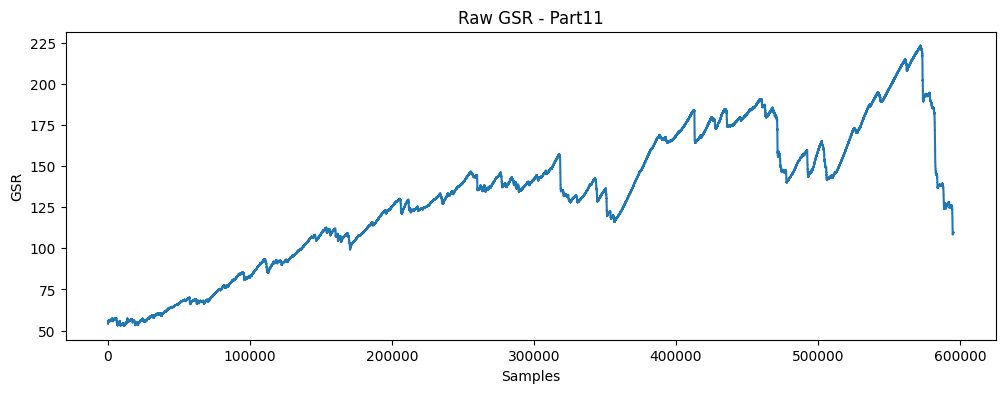

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

file = "../data/raw/Participants/Part31/full_gsr_ppg.csv"  # justera filnamn

df = pd.read_csv(file)

gsr = pd.to_numeric(df["gsr"], errors="coerce")

print("Basic stats:")
print(gsr.describe())

print("\nNaNs:", gsr.isna().sum())

# Plot
plt.figure(figsize=(12,4))
plt.plot(gsr.values)
plt.title("Raw GSR - Part11")
plt.xlabel("Samples")
plt.ylabel("GSR")
plt.show()